LAB lezione 3: Ising model

## **A simple Neural Network: feed-forward with linear activation functions**

The first model of Neural Network we're going to work with is the feed-forward, with a single layer (connecting the inputs with the outputs) and linear activation functions. In practice, we are implementing a linear, or better, an affine transformation:

\begin{equation}
   y_j = \sum_{i} W_{ij} x_i + b_i
\end{equation}

We want now to employ this model to compute the magnetization for an Ising system: recalling the definition for $M$, it is simple to predict the weights of our feed-forward model:

\begin{equation}
  W_{ij} = +1, \quad
  b_i = 0
\end{equation}

The architecture of the system, implying a single output (the magnetization) will have $N$ inputs (the number of spins in the system) and $1$ output:

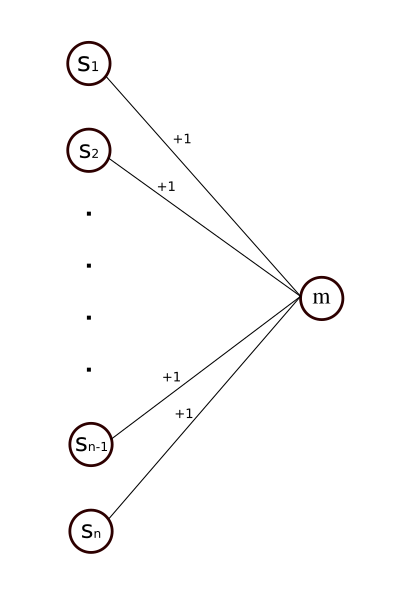

In fact, we're just evaluating a scalar product $\langle \vec W \cdot \vec s ⟩$, where $\vec s$ is the vector containing all the spin values, while $\vec W$ is a vector of $1$ elements. If instead we want to compute $m=M/N$, the weights $W_{1j}$ will be tuned as $1/N$.

**Goal**: the purpose of this exercise is to train a NN to predict the magnetization value. Given a specific $\{s \}_l$ configuration, the Feed-Forward model should be able to return the corresponding $m$ value.

**Steps**


1.   Instantiate the FeedForward class template
2.   Load the dataset (already in the main file)
3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the sub-dataset





In [ ]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os 

class NNIsing(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # DEFINE HERE THE LAYERS
        self.layers = nn.Sequential(
            nn.Linear(input_size, output_size)
        )
        
        #DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        #DEFINE HERE THE LOSS
        self.criterion = nn.MSELoss()

    def forward(self, x):
        #DEFINE HERE THE MODEL
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):
        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.model(inputs)
        labels = labels.unsqueeze(1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        return loss.item()


In [1]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os 

## main function ##
def main():

    # Load the dataset
    path = os.path.join(os.getcwd(), 'AI\ M4P-2.ipynb')
    with np.load(path) as loader:
      raw_data = np.load("ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]

    # Convert to tensor
    labels = torch.tensor(y_data, dtype=torch.float32)
    data = torch.tensor(x_data, dtype=torch.float32)

    # get the number of features (len_data, n_features)
    _, input_size = data.size()
    output_size = 1

    # We split the dataset into a training dataset and a test dataset. The former is used to train the model, while the
    # latter is used to evaluate the model performance
    # TODO: split the data into a training and a testing datasets (use "train_test_split" from sklearn.model_selection)
    # For further info: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.5)

    # Create dataset from several tensors with matching first dimension
    # Samples will be drawn from the first dimension (rows)
    dataset_train = TensorDataset(data_train, labels_train)
    dataset_test = TensorDataset(data_test, labels_test)
    # Create a data loader from the dataset
    # Batch size and number of workers are specified at this step
    loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)
    loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False)
    # We define the NN model
    # TODO: initialize the NN model
    nn_model = NNIsing(input_size, output_size)
    # Train model

    loss_evolution = []
    print("\n Training phase")

    for epoch, data in enumerate(loader_train):
        input_data, label = data
        loss_batches = []
        # TODO: train the model
        loss = nn_model.train_step(input_data, label)
        loss_batches.append(loss)
        
    mean_loss = np.mean(loss_batches)
    loss_evolution.append(mean_loss)

    #TODO: test the performance of the model using the test dataset
    print("\n Testing phase")
    test_losses = []
    with torch.no_grad():
        for input_data, label in loader_test:
            predictions = nn_model(input_data)
            label = label.view(-1, 1)
            loss = nn_model.criterion(predictions, label)
            test_losses.append(loss.item())
            
        mean_test_loss = np.mean(test_losses)

if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/francescopiosirignano/Desktop/Università/AI models for physics/AI\\ M4P-2.ipynb'

Completo


 Training phase...
Loss:  0.20013931393623352
Loss:  0.39922696352005005
Loss:  0.3750453591346741
Loss:  0.3882097899913788
Loss:  0.44121623039245605
Loss:  0.2039622962474823
Loss:  0.21849696338176727
Loss:  0.16351324319839478
Loss:  0.09431609511375427
Loss:  0.17926466464996338
Loss:  0.09098531305789948
Loss:  0.07199987769126892
Loss:  0.07166920602321625
Loss:  0.09462864696979523
Loss:  0.06654917448759079
Loss:  0.04008381441235542
Loss:  0.04508674889802933
Loss:  0.0740596130490303
Loss:  0.06562657654285431
Loss:  0.02992110140621662
Loss:  0.04885009303689003
Loss:  0.028802385553717613
Loss:  0.014899815432727337
Loss:  0.01747417077422142
Loss:  0.016575710847973824
Loss:  0.018393859267234802
Loss:  0.012680958956480026
Loss:  0.018841136246919632
Loss:  0.010746428743004799
Loss:  0.01493960153311491
Loss:  0.013638392090797424
Loss:  0.014097648672759533
Loss:  0.0032456854823976755
Loss:  0.0038900284562259912
Loss:  0.009613566100597382
Loss:  0.0051794932223856

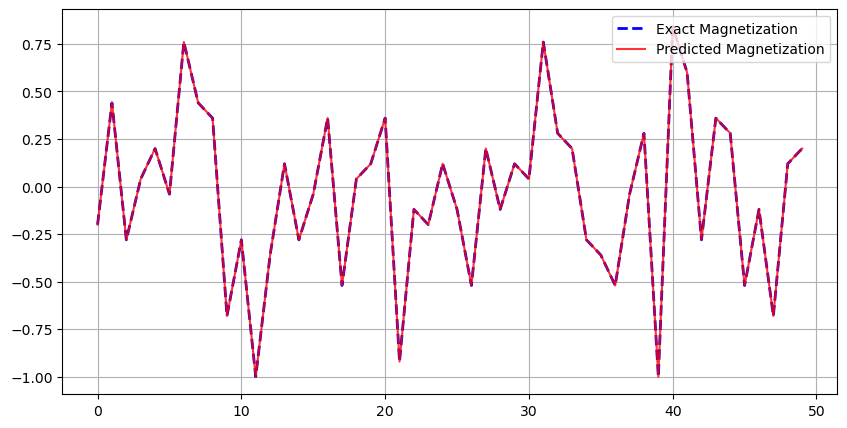

In [14]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os 

myseed = 42
np.random.seed(myseed)

class NNIsing(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # DEFINE HERE THE LAYERS
        self.model = nn.Sequential(
            nn.Linear(input_size, output_size)
        )
        
        #DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        #DEFINE HERE THE LOSS
        self.criterion = nn.MSELoss()

    def forward(self, x):
        #DEFINE HERE THE MODEL
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):
        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.model(inputs)
        labels = labels.unsqueeze(1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        return loss.item()

## main function ##
def main():

    # Load the dataset
    path = os.path.join(os.getcwd(), 'AI M4P-2.ipynb')
    
    raw_data = np.load("ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]

    # Convert to tensor
    labels = torch.tensor(y_data, dtype=torch.float32)
    data = torch.tensor(x_data, dtype=torch.float32)

    # get the number of features (len_data, n_features)
    _, input_size = data.size()
    output_size = 1

    # We split the dataset into a training dataset and a test dataset. The former is used to train the model, while the
    # latter is used to evaluate the model performance
    # TODO: split the data into a training and a testing datasets (use "train_test_split" from sklearn.model_selection)
    # For further info: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.5)

    # Create dataset from several tensors with matching first dimension
    # Samples will be drawn from the first dimension (rows)
    dataset_train = TensorDataset(data_train, labels_train)
    dataset_test = TensorDataset(data_test, labels_test)
    # Create a data loader from the dataset
    # Batch size and number of workers are specified at this step
    loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)
    loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False)
    # We define the NN model
    # TODO: initialize the NN model
    nn_model = NNIsing(input_size, output_size)
    # Train model

    loss_evolution = []
    n_epochs = 100
    print("\n Training phase...")
    for epoch in range(n_epochs): 
        loss_batches = []
        for data in loader_train:
            input_data, label = data
            # TODO: train the model
            loss = nn_model.train_step(input_data, label)
            loss_batches.append(loss)
            print(f'Loss: ', loss)

    # Visualizzazione della fase di training
    ''' plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs+1), loss_evolution, marker='o', color='purple')
    plt.title("Loss Function during Training")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show() '''

    #TODO: test the performance of the model using the test dataset
    print("\n Testing phase...")
    test_losses = []
    with torch.no_grad():
        for input_data, label in loader_test:
            predictions = nn_model(input_data)
            label = label.view(-1, 1)
            loss = nn_model.criterion(predictions, label)
            test_losses.append(loss.item())
            
        mean_test_loss = np.mean(test_losses)
   
    # Testiamo visivamente i primi 50 elementi per vedere se le curve si sovrappongono
    sample_inputs = data_test[:50]
    sample_labels = labels_test[:50]
    sample_preds = nn_model(sample_inputs).squeeze()

    plt.figure(figsize=(10, 5))
    plt.plot(sample_labels.numpy(), label="Exact Magnetization", linestyle='--', color='blue', linewidth=2)
    plt.plot(sample_preds.detach().numpy(), label="Predicted Magnetization", alpha=0.8, color='red')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

BINARY CLASSIFICATION FOR ISING MODEL


 Training phase...
Loss:  0.6229130625724792
Loss:  0.6797984838485718
Loss:  0.6431959867477417
Loss:  0.5330283641815186
Loss:  0.48433029651641846
Loss:  0.5658725500106812
Loss:  0.37139827013015747
Loss:  0.5786511898040771
Loss:  0.4945736825466156
Loss:  0.43605315685272217
Loss:  0.4576818346977234
Loss:  0.40681344270706177
Loss:  0.49679842591285706
Loss:  0.5383604764938354
Loss:  0.2462291419506073
Loss:  0.3919772207736969
Loss:  0.6255182027816772
Loss:  0.33278822898864746
Loss:  0.4655272364616394
Loss:  0.3317378759384155
Loss:  0.3576735556125641
Loss:  0.29252517223358154
Loss:  0.29484376311302185
Loss:  0.30898943543434143
Loss:  0.3208882212638855
Loss:  0.21962514519691467
Loss:  0.22815917432308197
Loss:  0.3320079743862152
Loss:  0.3397570550441742
Loss:  0.31156253814697266
Loss:  0.20671460032463074
Loss:  0.1988953948020935
Loss:  0.2509142756462097
Loss:  0.19199952483177185
Loss:  0.18517088890075684
Loss:  0.16737931966781616
Loss:  0.24297857284545898
L

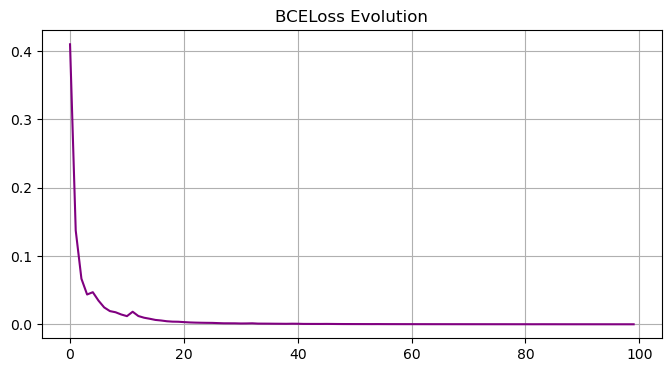


 Testing phase...


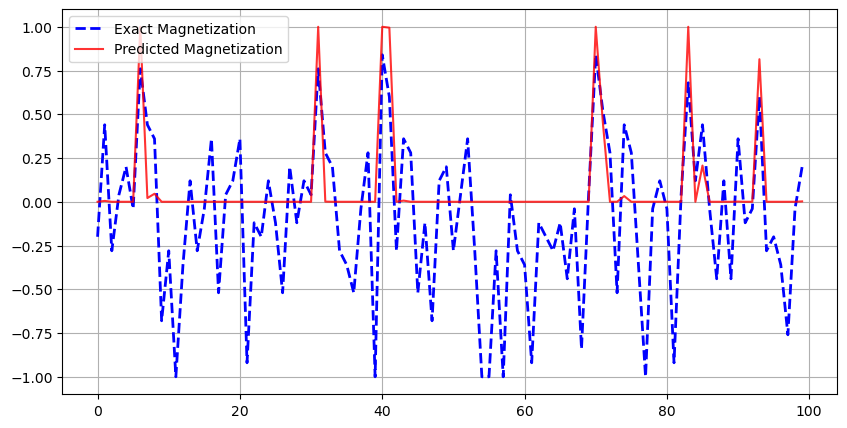

In [28]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os 

myseed = 42
np.random.seed(myseed)

class NNIsing(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # DEFINE HERE THE LAYERS
        self.model = nn.Sequential(nn.Linear(input_size, 20),
                                   nn.Tanh(),
                                   nn.Linear(20, output_size),
                                   nn.Sigmoid())
        
        #DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        #DEFINE HERE THE LOSS
        self.criterion = nn.BCELoss()

    def forward(self, x):
        #DEFINE HERE THE MODEL
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):
        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.model(inputs)
        labels[labels > 0.5] = 1
        labels[labels <= 0.5] = 0
        labels = labels.unsqueeze(1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        return loss.item()

## main function ##
def main():

    # Load the dataset
    path = os.path.join(os.getcwd(), 'AI M4P-2.ipynb')
    
    raw_data = np.load("ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]

    # Convert to tensor
    labels = torch.tensor(y_data, dtype=torch.float32)
    data = torch.tensor(x_data, dtype=torch.float32)

    # get the number of features (len_data, n_features)
    _, input_size = data.size()
    output_size = 1

    # We split the dataset into a training dataset and a test dataset. The former is used to train the model, while the
    # latter is used to evaluate the model performance
    # TODO: split the data into a training and a testing datasets (use "train_test_split" from sklearn.model_selection)
    # For further info: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.5)

    # Create dataset from several tensors with matching first dimension
    # Samples will be drawn from the first dimension (rows)
    dataset_train = TensorDataset(data_train, labels_train)
    dataset_test = TensorDataset(data_test, labels_test)
    # Create a data loader from the dataset
    # Batch size and number of workers are specified at this step
    loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)
    loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False)
    # We define the NN model
    # TODO: initialize the NN model
    nn_model = NNIsing(input_size, output_size)
    # Train model

    loss_evolution = []
    n_epochs = 100
    print("\n Training phase...")
    for epoch in range(n_epochs): 
        loss_batches = []
        for data in loader_train:
            input_data, label = data
            # TODO: train the model
            loss = nn_model.train_step(input_data, label)
            loss_batches.append(loss)
            print(f'Loss: ', loss)

        avg_loss = np.mean(loss_batches)
        loss_evolution.append(avg_loss)

    plt.figure(figsize=(8, 4))
    plt.plot(loss_evolution, color='purple')
    plt.title("BCELoss Evolution")
    plt.grid(True)
    plt.show() 

    #TODO: test the performance of the model using the test dataset
    print("\n Testing phase...")
    test_losses = []
    with torch.no_grad():
        for input_data, label in loader_test:
            predictions = nn_model(input_data)
            label[label > 0.5] = 1
            label[label <= 0.5] = 0
            label = label.view(-1, 1)
            loss = nn_model.criterion(predictions, label)
            test_losses.append(loss.item())
            
        mean_test_loss = np.mean(test_losses)
   
    # Testiamo visivamente i primi 50 elementi per vedere se le curve si sovrappongono
    sample_inputs = data_test[:100]
    sample_labels = labels_test[:100]
    sample_preds = nn_model(sample_inputs).squeeze()

    plt.figure(figsize=(10, 5))
    plt.plot(sample_labels.numpy(), label="Exact Magnetization", linestyle='--', color='blue', linewidth=2)
    plt.plot(sample_preds.detach().numpy(), label="Predicted Magnetization", alpha=0.8, color='red')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()